In [ ]:
!pip install torch-geometric rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 39.9 MB/s eta 0:00:00


# Import biblioteka

In [ ]:
import torch
from torch_geometric.datasets import MoleculeNet
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Analiza dataseta - ESOL i Tox21

## Učitavanje dataseta

In [ ]:
esol_dataset = MoleculeNet(root='data/', name='ESOL')
tox21_dataset = MoleculeNet(root='data/', name='Tox21')

print(f"ESOL: {len(esol_dataset)}")
print(f"Tox21: {len(tox21_dataset)}")

Processing...
Done!
Extracting data/tox21/raw/tox21.csv.gz
Processing...
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'NC(=O)NC1N=C(O[AlH3](O)O)NC1=O' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'O=CO[AlH3](OC=O)OC=O' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'CC(=O)O[AlH3](O)O' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'CC(=O)O[AlH3](O)OC(C)=O' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:265: UserWarning: Skipping molecule 'CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC' since it resulted in zero atoms
  self.process(

ESOL: 1128
Tox21: 7823


Done!


## Osnovne statistike dataseta

In [ ]:
def dataset_stats(dataset, name):
  num_atoms = [data.x.size(0) for data in dataset]
  num_edges = [data.edge_index.size(1) // 2 for data in dataset]

  stats = {
      'Dataset': name,
      'Broj molekula': len(dataset),
      'Značajki po atomu': dataset.num_features,
      'Značajki po vezi': dataset[0].edge_attr.size(1) if dataset[0].edge_attr is not None else 0,
      'Prosj. atoma': f"{np.mean(num_atoms):.1f}",
      'Min atoma': min(num_atoms),
      'Max atoma': max(num_atoms),
      'Prosj. veza': f"{np.mean(num_edges):.1f}",
  }
  return stats

stats_df = pd.DataFrame([dataset_stats(esol_dataset, 'ESOL'), dataset_stats(tox21_dataset, 'Tox21')])
stats_df

,Dataset,Broj molekula,Značajki po atomu,Značajki po vezi,Prosj. atoma,Min atoma,Max atoma,Prosj. veza
0,ESOL,1128,9,3,13.3,1,55,13.7
1,Tox21,7823,9,3,18.6,1,132,19.3


## ESOL - distribucija topljivosti

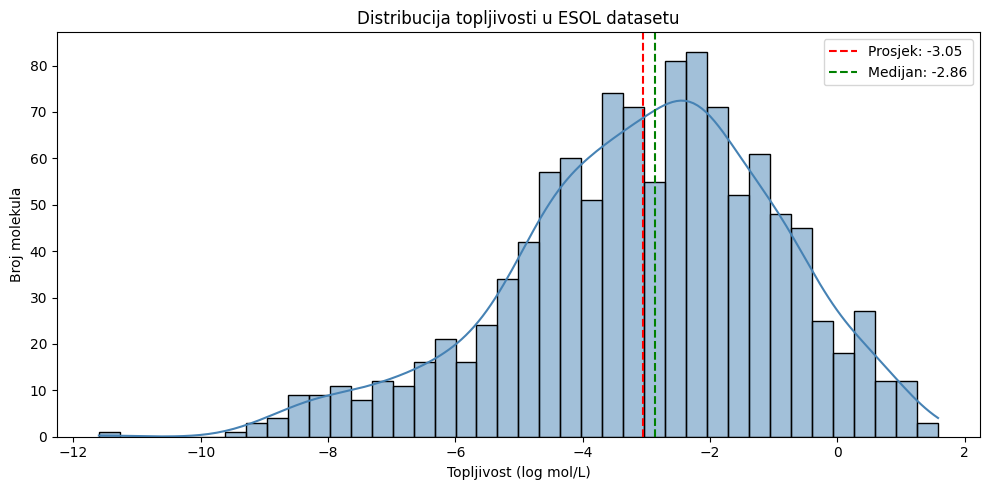

Min: -11.60 | Max: 1.58
Prosjek: -3.05 | Standardna devijacija: 2.10


In [ ]:
esol_y = np.array([data.y.item() for data in esol_dataset])

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(esol_y, bins=40, kde=True, ax=ax, color='steelblue')
ax.set_xlabel('Topljivost (log mol/L)')
ax.set_ylabel('Broj molekula')
ax.set_title('Distribucija topljivosti u ESOL datasetu')
ax.axvline(esol_y.mean(), color='red', linestyle='--', label=f'Prosjek: {esol_y.mean():.2f}')
ax.axvline(np.median(esol_y), color='green', linestyle='--', label=f'Medijan: {np.median(esol_y):.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min: {esol_y.min():.2f} | Max: {esol_y.max():.2f}")
print(f"Prosjek: {esol_y.mean():.2f} | Standardna devijacija: {esol_y.std():.2f}")

## 5. Tox21 — analiza 12 taskova toksičnosti

In [ ]:
task_names = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
              'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

tox21_y = np.array([data.y.numpy().flatten() for data in tox21_dataset])

task_stats = []
for i, name in enumerate(task_names):
    col = tox21_y[:, i]
    valid = col[~np.isnan(col)]
    task_stats.append({
        'Task': name,
        'Ukupno testirano': len(valid),
        'Toksično (1)': int((valid == 1).sum()),
        'Netoksično (0)': int((valid == 0).sum()),
        'NaN (netestirano)': int(np.isnan(col).sum()),
        '% toksičnih': f"{100 * (valid == 1).sum() / len(valid):.1f}%",
    })

tox_df = pd.DataFrame(task_stats)
tox_df

,Task,Ukupno testirano,Toksično (1),Netoksično (0),NaN (netestirano),% toksičnih
0,NR-AR,7258,308,6950,565,4.2%
1,NR-AR-LBD,6751,237,6514,1072,3.5%
2,NR-AhR,6542,768,5774,1281,11.7%
3,NR-Aromatase,5815,300,5515,2008,5.2%
4,NR-ER,6186,791,5395,1637,12.8%
5,NR-ER-LBD,6948,349,6599,875,5.0%
6,NR-PPAR-gamma,6443,186,6257,1380,2.9%
7,SR-ARE,5825,942,4883,1998,16.2%
8,SR-ATAD5,7065,264,6801,758,3.7%
9,SR-HSE,6460,372,6088,1363,5.8%


## 6. Vizualizacija neuravnoteženosti Tox21

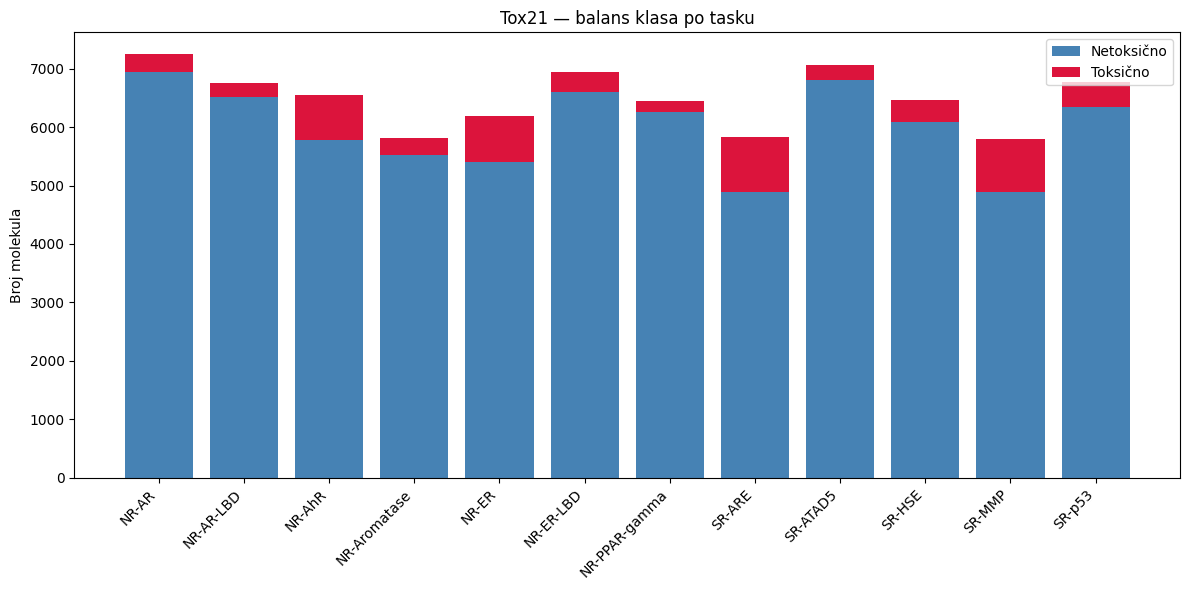

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(task_names))
toxic = [s['Toksično (1)'] for s in task_stats]
nontoxic = [s['Netoksično (0)'] for s in task_stats]

ax.bar(x, nontoxic, label='Netoksično', color='steelblue')
ax.bar(x, toxic, bottom=nontoxic, label='Toksično', color='crimson')

ax.set_xticks(x)
ax.set_xticklabels(task_names, rotation=45, ha='right')
ax.set_ylabel('Broj molekula')
ax.set_title('Tox21 — balans klasa po tasku')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Primjeri molekula iz ESOL dataseta


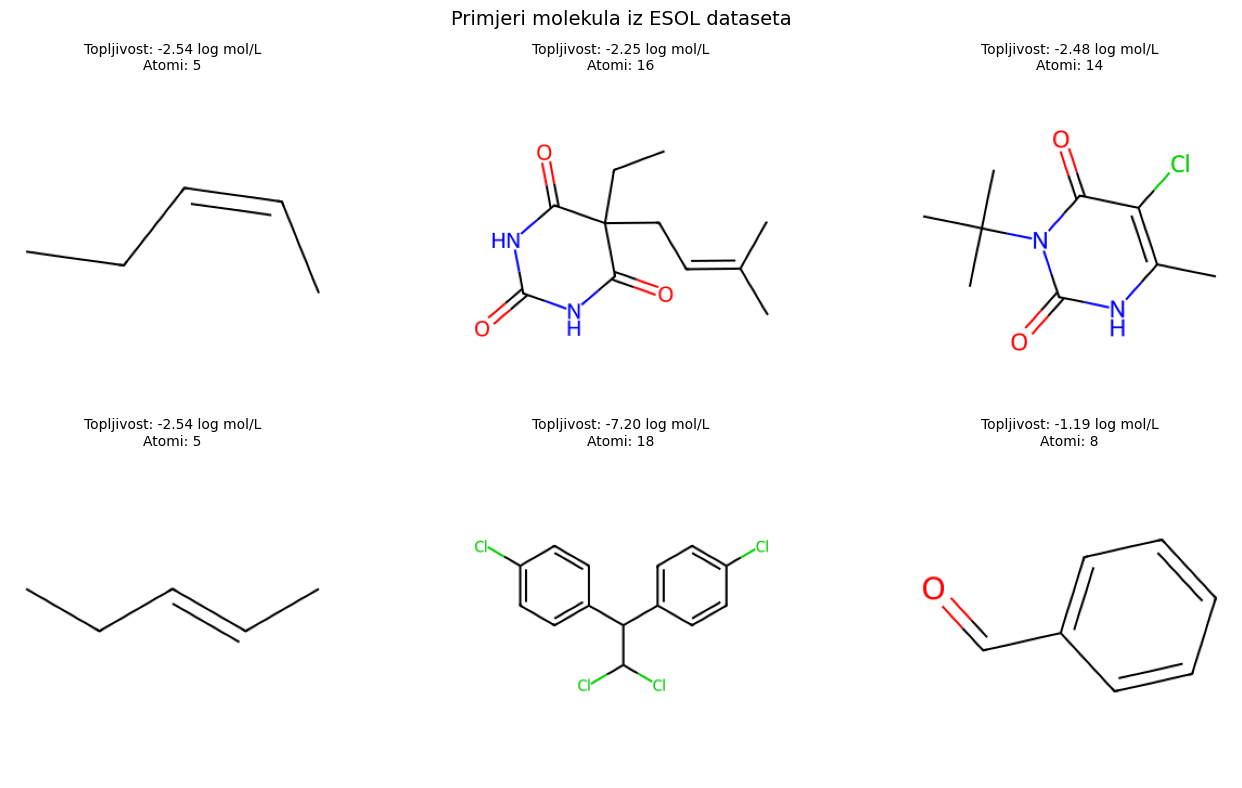

In [ ]:
np.random.seed(42)
indices = np.random.choice(len(esol_dataset), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, idx in zip(axes.flatten(), indices):
    data = esol_dataset[idx]
    mol = Chem.MolFromSmiles(data.smiles)
    img = Draw.MolToImage(mol, size=(300, 300))
    ax.imshow(img)
    ax.set_title(f"Topljivost: {data.y.item():.2f} log mol/L\nAtomi: {data.x.size(0)}", fontsize=10)
    ax.axis('off')

plt.suptitle('Primjeri molekula iz ESOL dataseta', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Primjeri molekula iz Tox21 dataseta

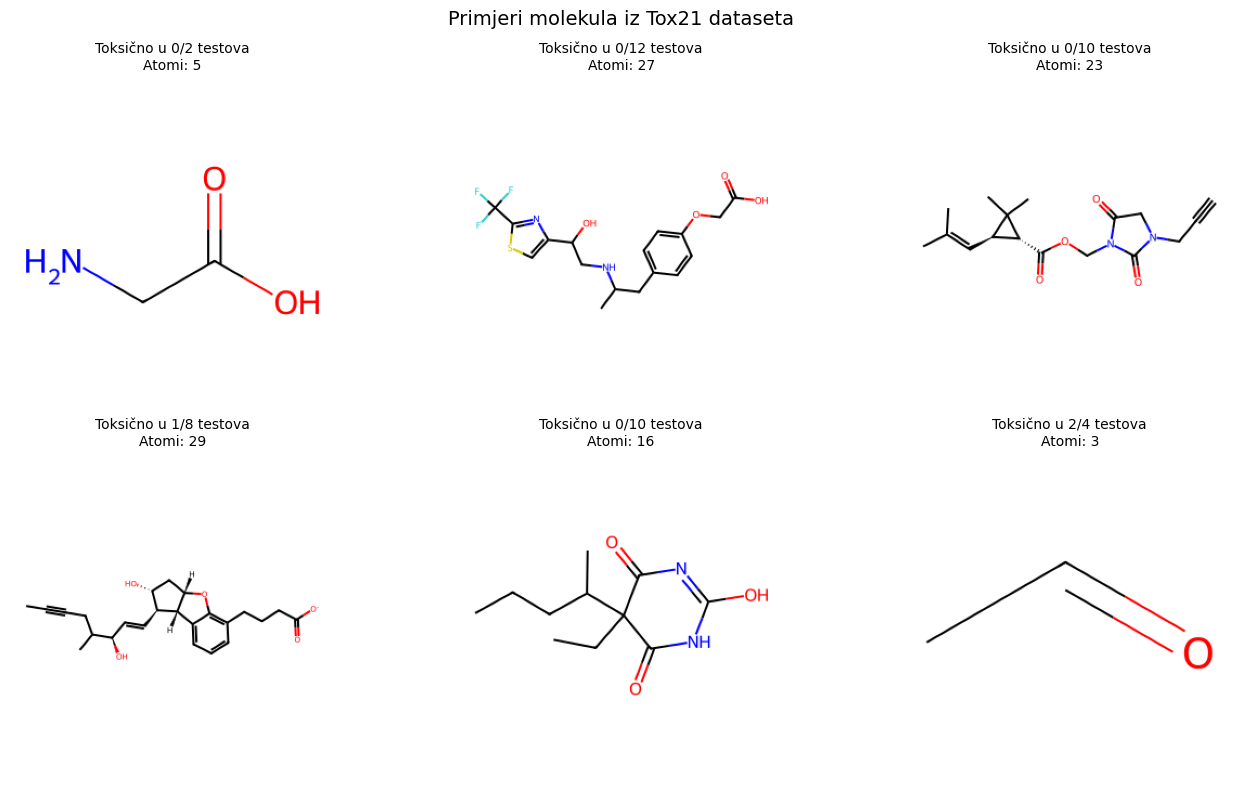

In [ ]:
np.random.seed(42)
indices = np.random.choice(len(tox21_dataset), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, idx in zip(axes.flatten(), indices):
    data = tox21_dataset[idx]
    mol = Chem.MolFromSmiles(data.smiles)
    if mol is None:
        ax.axis('off')
        continue

    img = Draw.MolToImage(mol, size=(300, 300))
    ax.imshow(img)

    labels = data.y.numpy().flatten()
    toxic_count = int(np.nansum(labels == 1))
    tested_count = int(np.sum(~np.isnan(labels)))

    ax.set_title(f"Toksično u {toxic_count}/{tested_count} testova\nAtomi: {data.x.size(0)}", fontsize=10)
    ax.axis('off')

plt.suptitle('Primjeri molekula iz Tox21 dataseta', fontsize=14)
plt.tight_layout()
plt.show()